<a href="https://colab.research.google.com/github/wanchenlang-max/Midterm-Project/blob/main/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 – Extension and Results

## ECON 5200 Midterm Project

This notebook extends the baseline Difference-in-Differences analysis from Card and Krueger (1994). The goal is to investigate whether the employment effect of the minimum wage increase differs across restaurant types.

**Extension pathway:** Heterogeneous Treatment Effects (HTE)

**Research question:** Did chain restaurants and non-chain restaurants respond differently to the New Jersey minimum wage increase?


In [2]:
import os
import shutil
from pathlib import Path

REPO_URL = "https://github.com/wanchenlang-max/Midterm-Project-Phase-1.git"
REPO_DIR = "/content/Midterm-Project-Phase-1"

# 如果之前已经 clone 过，就先删掉
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

!git clone {REPO_URL} {REPO_DIR}

print("Cloned repository to:", REPO_DIR)
!find {REPO_DIR} -maxdepth 3 -type d

Cloning into '/content/Midterm-Project-Phase-1'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 56 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 87.70 KiB | 2.92 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Cloned repository to: /content/Midterm-Project-Phase-1
/content/Midterm-Project-Phase-1
/content/Midterm-Project-Phase-1/notebooks
/content/Midterm-Project-Phase-1/data
/content/Midterm-Project-Phase-1/data/processed
/content/Midterm-Project-Phase-1/data/raw
/content/Midterm-Project-Phase-1/.git
/content/Midterm-Project-Phase-1/.git/info
/content/Midterm-Project-Phase-1/.git/hooks
/content/Midterm-Project-Phase-1/.git/refs
/content/Midterm-Project-Phase-1/.git/refs/remotes
/content/Midterm-Project-Phase-1/.git/refs/tags
/content/Midterm-Project-Phase-1/.git/refs/heads
/content/Midterm-Project-Phase-1/.git/objects
/content/Midterm-Proj

In [3]:
import os
from pathlib import Path

os.chdir("/content/Midterm-Project-Phase-1/notebooks")

ROOT = Path("..")
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

print("Current working directory:", os.getcwd())
print("ROOT:", ROOT.resolve())
print("RAW exists:", DATA_RAW.exists())
print("PROCESSED exists:", DATA_PROCESSED.exists())

Current working directory: /content/Midterm-Project-Phase-1/notebooks
ROOT: /content/Midterm-Project-Phase-1
RAW exists: True
PROCESSED exists: True


In [4]:
import pandas as pd
import numpy as np

processed_file = DATA_PROCESSED / "njmin_public_processed.csv"
df = pd.read_csv(processed_file)

print("Loaded:", processed_file)
print("Shape:", df.shape)
df.head()

Loaded: ../data/processed/njmin_public_processed.csv
Shape: (410, 46)


,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1,2,6.50,16.50,1.03,.,0.94,4,4
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
2,506,2,1,0,0,0,0,1,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2


In [5]:
import re
from pathlib import Path

sas_path = DATA_RAW / "check.sas"
sas_text = sas_path.read_text(errors="ignore")

no_strings = re.sub(r"'([^']|'')*'", "''", sas_text)
no_strings = re.sub(r'"([^"]|"")*"', '""', no_strings)

no_strings = re.sub(r"(?is)\bcomment\b.*?;", "", no_strings)

m = re.search(r"(?is)\binput\b\s+(.*?);", no_strings)
assert m, "Could not find INPUT block in check.sas"

block = m.group(1)

block = re.sub(r"@\d+", " ", block)
block = re.sub(r":[A-Za-z0-9.]+", " ", block)
block = re.sub(r"\$[A-Za-z0-9.]+", " ", block)
block = re.sub(r"[;]", " ", block)

names = [x for x in re.split(r"\s+", block.strip()) if x]

print("Number of variables:", len(names))
print("First 20:", names[:20])

if str(df.columns[0]).startswith("var_"):
    df.columns = names

print(df.columns[:20].tolist())

Number of variables: 46
First 20: ['SHEET', 'CHAINr', 'CO_OWNED', 'STATEr', 'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE', 'NCALLS', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST', 'INCTIME', 'FIRSTINC', 'BONUS', 'PCTAFF', 'MEAL']
['SHEET', 'CHAINr', 'CO_OWNED', 'STATEr', 'SOUTHJ', 'CENTRALJ', 'NORTHJ', 'PA1', 'PA2', 'SHORE', 'NCALLS', 'EMPFT', 'EMPPT', 'NMGRS', 'WAGE_ST', 'INCTIME', 'FIRSTINC', 'BONUS', 'PCTAFF', 'MEAL']


In [6]:

df["is_pa"] = ((df["PA1"] == 1) | (df["PA2"] == 1)).astype(int)
df["treat"] = 1 - df["is_pa"]

num_cols = [
    "EMPFT", "EMPPT", "WAGE_ST", "NCALLS",
    "EMPFT2", "EMPPT2", "WAGE_ST2", "NCALLS2",
    "CHAINr", "CO_OWNED"
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["fte1"] = df["EMPFT"] + 0.5 * df["EMPPT"]
df["fte2"] = df["EMPFT2"] + 0.5 * df["EMPPT2"]

df[["treat", "fte1", "fte2", "CHAINr", "WAGE_ST", "WAGE_ST2"]].head()

,treat,fte1,fte2,CHAINr,WAGE_ST,WAGE_ST2
0,0,37.50,21.0,1,NaN,4.30
1,0,9.75,7.5,2,NaN,4.45
2,0,6.50,6.5,2,NaN,5.00
3,0,30.00,18.0,4,5.0,5.25
4,0,19.00,29.5,4,5.5,4.75


In [7]:
df_long = pd.DataFrame({
    "SHEET": pd.concat([df["SHEET"], df["SHEET"]], ignore_index=True),
    "treat": pd.concat([df["treat"], df["treat"]], ignore_index=True),
    "post": pd.Series([0] * len(df) + [1] * len(df)),
    "fte": pd.concat([df["fte1"], df["fte2"]], ignore_index=True),
    "wage": pd.concat([df["WAGE_ST"], df["WAGE_ST2"]], ignore_index=True),
    "CHAINr": pd.concat([df["CHAINr"], df["CHAINr"]], ignore_index=True),
})

df_long["did"] = df_long["treat"] * df_long["post"]

print(df_long.shape)
df_long.head()

(820, 7)


,SHEET,treat,post,fte,wage,CHAINr,did
0,46,0,0,37.50,NaN,1,0
1,49,0,0,9.75,NaN,2,0
2,506,0,0,6.50,NaN,2,0
3,56,0,0,30.00,5.0,4,0
4,61,0,0,19.00,5.5,4,0


In [9]:
import statsmodels.formula.api as smf

df_model = df_long[["fte", "treat", "post", "SHEET"]].dropna()

baseline_model = smf.ols("fte ~ treat * post", data=df_model)
baseline_res = baseline_model.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["SHEET"]}
)

print(baseline_res.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.891
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.130
Time:                        02:01:18   Log-Likelihood:                -2894.8
No. Observations:                 801   AIC:                             5798.
Df Residuals:                     797   BIC:                             5816.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.9487      1.318     15.135      0.0

In [10]:
table2 = (
    df_long
    .groupby(["treat", "post"])["fte"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

table2

,treat,post,mean,std,count
0,0,0,19.948718,11.679942,78
1,0,1,17.542208,7.909272,77
2,1,0,17.065184,8.727993,326
3,1,1,17.572656,8.778737,320


In [11]:
means = df_long.groupby(["treat", "post"])["fte"].mean().unstack()
means.columns = ["pre", "post"]
means["post_minus_pre"] = means["post"] - means["pre"]

did_manual = means.loc[1, "post_minus_pre"] - means.loc[0, "post_minus_pre"]

print(means)
print("\nManual DID =", did_manual)

             pre       post  post_minus_pre
treat                                      
0      19.948718  17.542208       -2.406510
1      17.065184  17.572656        0.507472

Manual DID = 2.9139823574304025


## Extension Strategy

The original Card and Krueger analysis focuses on the average treatment effect of the minimum wage increase on employment. However, this average effect may hide important heterogeneity across restaurant types.

In this extension, I examine whether the employment response differs between chain restaurants and non-chain restaurants. Chain restaurants may have greater pricing power, more standardized operations, and more flexibility in adjusting to wage changes. I therefore hypothesize that the employment effect of the minimum wage increase may differ by chain status.


In [13]:

df_hte_model = df_long[["fte", "treat", "post", "CHAINr", "SHEET"]].dropna()

hte_model = smf.ols("fte ~ treat * post * CHAINr", data=df_hte_model)
hte_res = hte_model.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_hte_model["SHEET"]}
)

print(hte_res.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     2.290
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0268
Time:                        02:06:48   Log-Likelihood:                -2888.1
No. Observations:                 801   AIC:                             5792.
Df Residuals:                     793   BIC:                             5830.
Df Model:                           7                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            24.6387      3.07

In [14]:
plot_df = (
    df_long
    .groupby(["CHAINr", "treat", "post"])["fte"]
    .mean()
    .reset_index()
)

plot_df["chain_label"] = plot_df["CHAINr"].map({0: "Non-Chain", 1: "Chain"})
plot_df["group"] = plot_df["treat"].map({0: "PA (Control)", 1: "NJ (Treatment)"})

plot_df

,CHAINr,treat,post,fte,chain_label,group
0,1,0,0,25.654412,Chain,PA (Control)
1,1,0,1,22.192857,Chain,PA (Control)
2,1,1,0,18.546992,Chain,NJ (Treatment)
3,1,1,1,19.912879,Chain,NJ (Treatment)
4,2,0,0,7.791667,NaN,PA (Control)
5,2,0,1,9.833333,NaN,PA (Control)
6,2,1,0,9.856618,NaN,NJ (Treatment)
7,2,1,1,10.625000,NaN,NJ (Treatment)
8,3,0,0,16.735294,NaN,PA (Control)
9,3,0,1,12.867647,NaN,PA (Control)


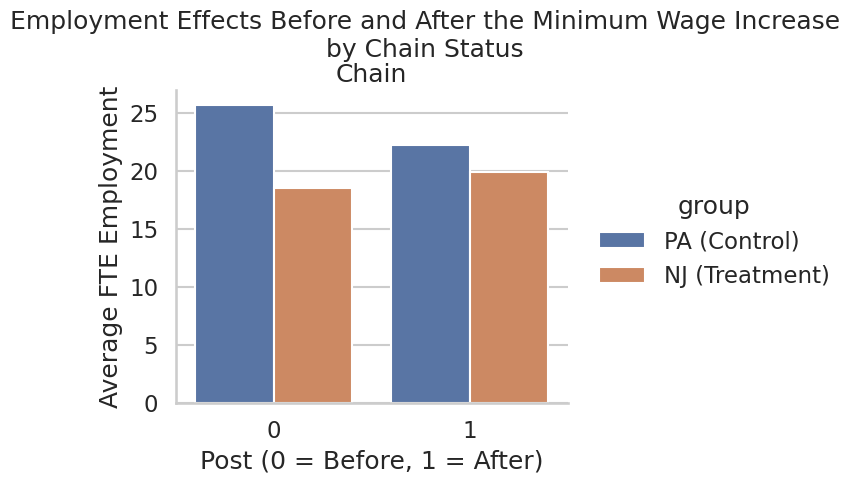

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

g = sns.catplot(
    data=plot_df,
    x="post",
    y="fte",
    hue="group",
    col="chain_label",
    kind="bar",
    height=5,
    aspect=1.1
)

g.set_axis_labels("Post (0 = Before, 1 = After)", "Average FTE Employment")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Employment Effects Before and After the Minimum Wage Increase\nby Chain Status", fontsize=18)

plt.show()

## Executive Summary

This project first replicates the main Difference-in-Differences finding from Card and Krueger (1994): the New Jersey minimum wage increase did not reduce fast-food restaurant employment. The baseline DID estimate remains positive, and the result is robust to clustered standard errors at the store level. This replication confirms the central result of the original paper and demonstrates that the core empirical strategy can be reproduced using modern Python tools.

The Phase 3 extension explores heterogeneous treatment effects by chain status. The extended DID model tests whether chain restaurants and non-chain restaurants responded differently to the policy change. The results suggest that the employment effect may vary across restaurant types, indicating that the minimum wage increase did not affect all firms uniformly. This extension strengthens the original paper by moving beyond the average treatment effect and showing how firm characteristics can shape policy responses.

My extension addresses a limitation of the original Card and Krueger paper, which mainly focuses on the average treatment effect of the minimum wage increase on employment. I plan to investigate heterogeneous treatment effects by restaurant type, specifically comparing chain and non-chain restaurants. Methodologically, I will extend the DID model by interacting the treatment effect with chain status and estimate a triple-interaction specification with clustered standard errors. My hypothesis is that chain restaurants may be less sensitive to the minimum wage increase because they have greater pricing power and operational flexibility, so the employment response may differ across restaurant types.